# UTS - CLUSTERING EMAIL

In [1]:
!pip install Sastrawi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.2 MB/s eta 0:00:00


# **Load Dataset**

In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/PPW (1)/UTS/spam.csv'

# Coba baca pakai encoding alternatif
df = pd.read_csv(file_path, encoding='latin-1')  # atau encoding='ISO-8859-1'

# Lihat 5 baris pertama
df.head()


,id,Text,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,1,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,2,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,3,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,4,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,5,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.isnull().sum()

,0
id,0
Text,0
Unnamed: 2,5522
Unnamed: 3,5560
Unnamed: 4,5566


In [4]:
# Hapus kolom yang tidak diperlukan
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])

# Cek hasilnya
# print(df.info())
df.head()


,id,Text
0,1,"Go until jurong point, crazy.. Available only ..."
1,2,Ok lar... Joking wif u oni...
2,3,Free entry in 2 a wkly comp to win FA Cup fina...
3,4,U dun say so early hor... U c already then say...
4,5,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

# **Preprocessing**


## **Cleaning**

In [6]:
import pandas as pd
import re

# Fungsi cleansing
def cleansing(text):
    text = str(text).lower()                  # ubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # hilangkan angka, tanda baca, simbol
    text = re.sub(r'\s+', ' ', text).strip() # hilangkan spasi berlebih
    return text

# Terapkan cleansing pada kolom 'isi_berita' saja
df['cleaned'] = df['Text'].apply(cleansing)

# Simpan hasil dengan kolom kategori_berita tetap ikut
df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/spam_cleaned', index=False)
print("✅ Data berhasil dibersihkan dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (kolom isi_berita, cleaned, kategori_berita)
df[['Text', 'cleaned']].head(10)


✅ Data berhasil dibersihkan dan disimpan ke CSV!



,Text,cleaned
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling it s been week s now...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...


## **Stopwords**

In [7]:
import pandas as pd
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = str(text).split()
    filtered_words = [w for w in words if w.lower() not in stop_words]
    return ' '.join(filtered_words)

# Terapkan stopword removal pada kolom 'cleaned' saja
df['no_stopwords'] = df['cleaned'].apply(remove_stopwords)

# Simpan hasil ke CSV (kategori tetap ikut)
df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/spam_no_stopwords.csv', index=False)
print("✅ Data berhasil dihapus stopwords-nya (English) dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (termasuk kolom kategori)
df[['cleaned', 'no_stopwords']].head(10)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✅ Data berhasil dihapus stopwords-nya (English) dan disimpan ke CSV!



,cleaned,no_stopwords
0,go until jurong point crazy available only in ...,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni,ok lar joking wif u oni
2,free entry in a wkly comp to win fa cup final ...,free entry wkly comp win fa cup final tkts st ...
3,u dun say so early hor u c already then say,u dun say early hor u c already say
4,nah i don t think he goes to usf he lives arou...,nah think goes usf lives around though
5,freemsg hey there darling it s been week s now...,freemsg hey darling week word back like fun st...
6,even my brother is not like to speak with me t...,even brother like speak treat like aids patent
7,as per your request melle melle oru minnaminun...,per request melle melle oru minnaminunginte nu...
8,winner as a valued network customer you have b...,winner valued network customer selected receiv...
9,had your mobile months or more u r entitled to...,mobile months u r entitled update latest colou...


In [8]:
!pip install pyspellchecker


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 57.4 MB/s eta 0:00:00


In [10]:
from spellchecker import SpellChecker

# Inisialisasi spellchecker untuk bahasa Inggris
spell = SpellChecker(language='en')

def correct_spelling(text):
    words = str(text).split()
    corrected_words = []
    for w in words:
        if w.isalpha():  # hanya untuk kata alfabet
            correction = spell.correction(w)
            corrected_words.append(correction if correction is not None else w)
        else:
            corrected_words.append(w)
    return ' '.join(corrected_words)

# Terapkan spell checker pada kolom 'no_stopwords'
df['spell_checked'] = df['no_stopwords'].apply(correct_spelling)

# Simpan hasil akhir ke CSV
df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/spam_spellchecked.csv', index=False)
print("✅ Koreksi ejaan (English Spell Checker) selesai dan disimpan ke CSV!\n")

# Lihat hasil awal
df[['no_stopwords', 'spell_checked']].head(10)


✅ Koreksi ejaan (English Spell Checker) selesai dan disimpan ke CSV!



,no_stopwords,spell_checked
0,go jurong point crazy available bugis n great ...,go wrong point crazy available bugs n great wo...
1,ok lar joking wif u oni,ok lar joking if u on
2,free entry wkly comp win fa cup final tkts st ...,free entry wily come win fa cup final tits st ...
3,u dun say early hor u c already say,u dun say early for u c already say
4,nah think goes usf lives around though,nah think goes us lives around though
5,freemsg hey darling week word back like fun st...,freeing hey darling week word back like fun st...
6,even brother like speak treat like aids patent,even brother like speak treat like aids patent
7,per request melle melle oru minnaminunginte nu...,per request belle belle or minnaminunginte nur...
8,winner valued network customer selected receiv...,winner valued network customer selected receiv...
9,mobile months u r entitled update latest colou...,mobile months u r entitled update latest color...


## **Stemming**

In [ ]:
import pandas as pd
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Buat stemmer
stemmer = StemmerFactory().create_stemmer()

# Terapkan stemming pada kolom 'no_stopwords'
df['stemmed'] = df['no_stopwords'].apply(stemmer.stem)

# Simpan hasil ke CSV (kategori tetap ikut)
df.to_csv('/content/drive/MyDrive/PPW (1)/UTS/spam_stemming.csv', index=False)
print("✅ Data berhasil distemming dan disimpan ke CSV!\n")

# Tampilkan beberapa baris pertama (termasuk kolom kategori)
df[['no_stopwords', 'stemmed']].head(10)


✅ Data berhasil distemming dan disimpan ke CSV!



,no_stopwords,stemmed
0,go jurong point crazy available bugis n great ...,go jurong point crazy available bugis n great ...
1,ok lar joking wif u oni,ok lar joking wif u oni
2,free entry wkly comp win fa cup final tkts st ...,free entry wkly comp win fa cup final tkts st ...
3,u dun say early hor u c already say,u dun say early hor u c already say
4,nah think goes usf lives around though,nah think goes usf lives around though
5,freemsg hey darling week word back like fun st...,freemsg hey darling week word back like fun st...
6,even brother like speak treat like aids patent,even brother like speak treat like aids patent
7,per request melle melle oru minnaminunginte nu...,per request melle melle oru minnaminunginte nu...
8,winner valued network customer selected receiv...,winner valued network customer selected receiv...
9,mobile months u r entitled update latest colou...,mobile months u r entitled update latest colou...


In [13]:
# Jumlah data awal sebelum drop NaN
total_awal = len(df)
print("Jumlah data awal:", total_awal)

# Jumlah data setelah drop NaN
total_setelah_drop = len(df)
print("Jumlah data setelah drop NaN:", total_setelah_drop)


Jumlah data awal: 5572
Jumlah data setelah drop NaN: 5572


## **Tokenisasi**

In [15]:
import pandas as pd

# Muat ulang data hasil stemming
df = pd.read_csv('/content/drive/MyDrive/PPW (1)/UTS/spam_stemming.csv')

# Pastikan semua nilai di kolom 'stemmed' berupa string
df['stemmed'] = df['stemmed'].fillna("").astype(str)

# Tokenisasi sederhana (pisah berdasarkan spasi)
df['tokens'] = df['stemmed'].apply(lambda x: x.split())

# Simpan hasil
output_path = '/content/drive/MyDrive/PPW (1)/UTS/spam_tokenized.csv'
df.to_csv(output_path, index=False)

print("✅ Tokenisasi berhasil tanpa error dan disimpan ke:", output_path)
display(df[['stemmed', 'tokens']].head(10))


✅ Tokenisasi berhasil tanpa error dan disimpan ke: /content/drive/MyDrive/PPW (1)/UTS/spam_tokenized.csv


,stemmed,tokens
0,go jurong point crazy available bugis n great ...,"[go, jurong, point, crazy, available, bugis, n..."
1,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,free entry wkly comp win fa cup final tkts st ...,"[free, entry, wkly, comp, win, fa, cup, final,..."
3,u dun say early hor u c already say,"[u, dun, say, early, hor, u, c, already, say]"
4,nah think goes usf lives around though,"[nah, think, goes, usf, lives, around, though]"
5,freemsg hey darling week word back like fun st...,"[freemsg, hey, darling, week, word, back, like..."
6,even brother like speak treat like aids patent,"[even, brother, like, speak, treat, like, aids..."
7,per request melle melle oru minnaminunginte nu...,"[per, request, melle, melle, oru, minnaminungi..."
8,winner valued network customer selected receiv...,"[winner, valued, network, customer, selected, ..."
9,mobile months u r entitled update latest colou...,"[mobile, months, u, r, entitled, update, lates..."


# **Corpus**

In [20]:
corpus = df['tokens'].apply(lambda toks: " ".join(ast.literal_eval(toks))
                            if isinstance(toks, str) else " ".join(toks)).tolist()
corpus

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think goes usf lives around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aids patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune callers press copy friends callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hours',
 'mobile months u r entitled update latest colour mobiles camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chances win cash pounds txt csh send cost p day days tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd po

# **TF-IDF**

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

In [24]:
# Inisialisasi vectorizer
vectorizer = TfidfVectorizer()

print("TfidfVectorizer diinisialisasi.")

TfidfVectorizer diinisialisasi.


In [25]:
# Ubah teks menjadi matriks TF-IDF
X_tfidf = vectorizer.fit_transform(corpus)
# Tampilkan ukuran matriks
print("Ukuran matriks TF-IDF:", X_tfidf.shape)  # (jumlah dokumen, jumlah kosakata)

Ukuran matriks TF-IDF: (5572, 7538)


In [26]:
# === 4️⃣ Ubah ke DataFrame biar bisa dilihat seperti tabel ===
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=vectorizer.get_feature_names_out()
)
# === 6️⃣ Simpan hasil ke CSV ===
output_path = '/content/drive/MyDrive/PPW (1)/UTS/tfidf_spam.csv'
tfidf_df.to_csv(output_path, index=False)

print(f"📁 TF-IDF matrix dengan kolom kategori berhasil disimpan ke:\n{output_path}")

# === 7️⃣ Tampilkan beberapa baris pertama ===
tfidf_df.head(10)

📁 TF-IDF matrix dengan kolom kategori berhasil disimpan ke:
/content/drive/MyDrive/PPW (1)/UTS/tfidf_spam.csv


,aa,aah,aaniye,aaooooright,aathi,ab,abbey,abdomen,abeg,abel,...,zeros,zf,zhong,zindgi,zoe,zogtorius,zoom,zouk,zs,zyada
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Elbow Method**

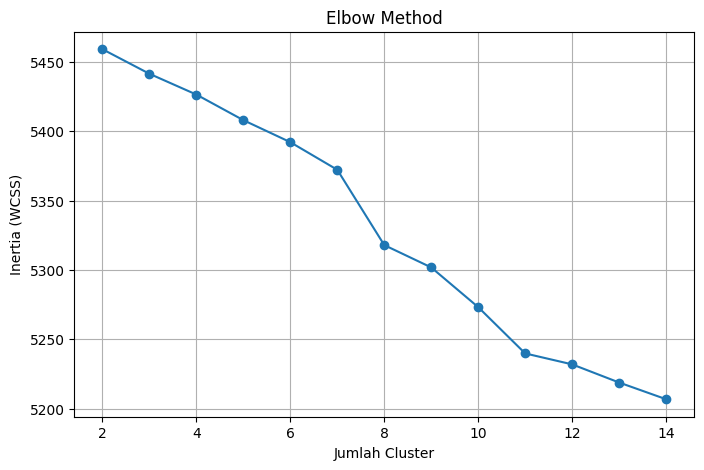

In [38]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
range_n_clusters = range(2, 15)

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia (WCSS)')
plt.grid(True)
plt.show()


# **Silhouette Score**

Cluster 2: Silhouette Score = 0.0050
Cluster 3: Silhouette Score = 0.0057
Cluster 4: Silhouette Score = 0.0064
Cluster 5: Silhouette Score = 0.0070
Cluster 6: Silhouette Score = 0.0074
Cluster 7: Silhouette Score = 0.0087
Cluster 8: Silhouette Score = 0.0132
Cluster 9: Silhouette Score = 0.0137
Cluster 10: Silhouette Score = 0.0134
Cluster 11: Silhouette Score = 0.0162
Cluster 12: Silhouette Score = 0.0166
Cluster 13: Silhouette Score = 0.0172
Cluster 14: Silhouette Score = 0.0179


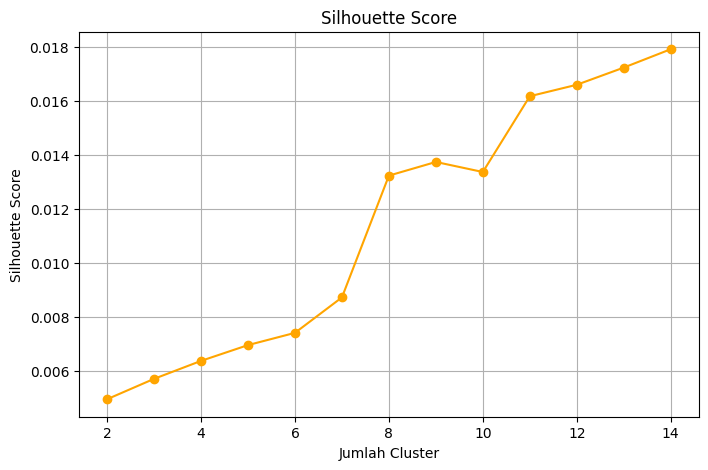

In [39]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    silhouette_scores.append(score)
    print(f"Cluster {n_clusters}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range_n_clusters, silhouette_scores, marker='o', color='orange')
plt.title('Silhouette Score')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()


# **K-Means**

In [41]:
optimal_clusters = 14  # berdasarkan silhouette tertinggi

kmeans_optimal = KMeans(n_clusters=optimal_clusters, random_state=42)
labels_optimal = kmeans_optimal.fit_predict(X)

tfidf_df['Cluster'] = labels_optimal
tfidf_df.head()


,aa,aah,aaniye,aaooooright,aathi,ab,abbey,abdomen,abeg,abel,...,zf,zhong,zindgi,zoe,zogtorius,zoom,zouk,zs,zyada,Cluster
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13


# **Jumlah Dokumen per Cluster**

In [44]:
import pandas as pd

df_cluster_count = pd.DataFrame({
    'Cluster': jumlah_dokumen_per_cluster.index,
    'Jumlah Dokumen': jumlah_dokumen_per_cluster.values
})

df_cluster_count


,Cluster,Jumlah Dokumen
0,0,173
1,1,322
2,2,186
3,3,47
4,4,170
5,5,509
6,6,156
7,7,220
8,8,95
9,9,242


In [50]:
import pandas as pd

# Copy dataframe dan tambahkan label cluster
df_with_cluster = df.copy()
df_with_cluster['Cluster'] = tfidf_df['Cluster'].values

# List untuk menampung data contoh per cluster
list_contoh = []

# Ambil 3 contoh dokumen per cluster
for cluster_num in sorted(df_with_cluster['Cluster'].unique()):
    contoh = df_with_cluster[df_with_cluster['Cluster'] == cluster_num]['Text'].head(3)
    for doc in contoh:
        list_contoh.append({
            'Cluster': cluster_num,
            'Dokumen': doc[:200]  # 200 karakter pertama
        })

# Buat DataFrame hasil
df_contoh_per_cluster = pd.DataFrame(list_contoh)

# Tampilkan
df_contoh_per_cluster


,Cluster,Dokumen
0,0,FreeMsg Hey there darling it's been 3 week's n...
1,0,Even my brother is not like to speak with me. ...
2,0,Ahhh. Work. I vaguely remember that! What does...
3,1,Free entry in 2 a wkly comp to win FA Cup fina...
4,1,Had your mobile 11 months or more? U R entitle...
5,1,"SIX chances to win CASH! From 100 to 20,000 po..."
6,2,Ha ha ha good joke. Girls are situation seekers.
7,2,"Good stuff, will do."
8,2,"Hello, my love. What are you doing? Did you ge..."
9,3,"Sorry, I'll call later in meeting."


# **Visualisasi PCA**

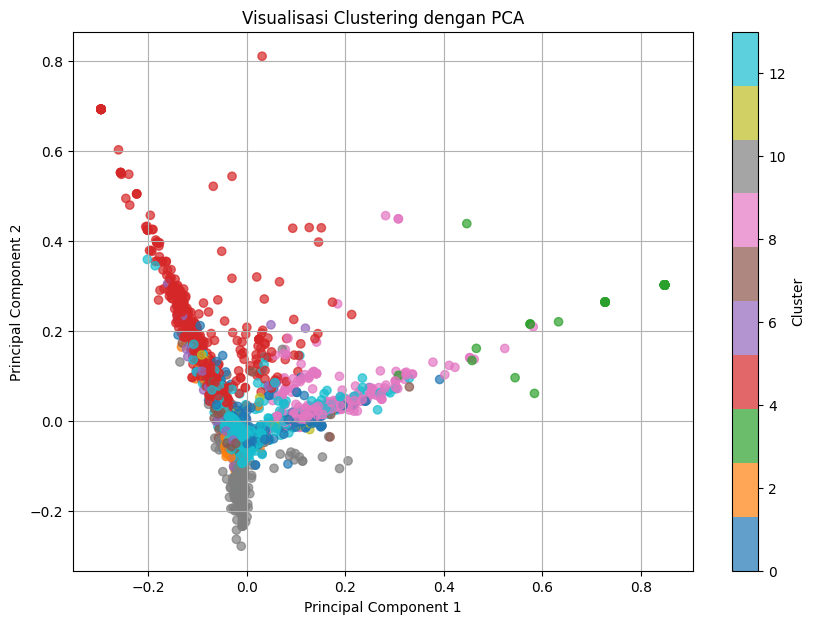

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Asumsikan X adalah matriks fitur (TF-IDF) dan tfidf_df['Cluster'] sudah ada

# 1. Turunkan dimensi ke 2D dengan PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X.toarray())  # kalau X sparse matrix, ubah ke array dulu

# 2. Buat DataFrame untuk plotting
import pandas as pd
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Cluster'] = tfidf_df['Cluster'].values

# 3. Visualisasi scatter plot dengan warna cluster
plt.figure(figsize=(10,7))
scatter = plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df_pca['Cluster'], cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label='Cluster')
plt.title('Visualisasi Clustering dengan PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()
